<a href="https://colab.research.google.com/github/Yurida26/UTS-NLP-SemanticSquad/blob/main/2_Preprocessing_Product_Category.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook ini mencakup:

1. **Cleaning:** Menghapus karakter tidak penting (URL, angka, tanda baca).
2. **Filtering:** Menghapus kata umum yang tidak bermakna (Stopwords).
3. **Stemming:** Mengembalikan kata ke bentuk dasarnya (Bahasa Indonesia).
4. **Labeling:** Mengonversi kategori produk menjadi label numerik.

**Install Library Sastrawi**

In [1]:
# Install library Sastrawi untuk Stemming bahasa Indonesia
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.8 MB/s eta 0:00:00


**DATA LOADING**

Memuat dan Menyiapkan Data

In [3]:
import pandas as pd

# Load data hasil sampling
file_input = 'dataset_uts_12k_balanced.csv'

try:
    df = pd.read_csv(file_input)
    # 1. Pilih kolom yang penting saja
    df = df[['product_name', 'review_text', 'product_category']]

    # 2. Hapus baris yang kosong (NaN) agar proses cleaning tidak error
    df = df.dropna(subset=['review_text', 'product_category'])

    # 3. Gabungkan nama produk dan review agar fitur kata-katanya lebih kaya
    df['text_combined'] = df['product_name'] + " " + df['review_text']

    print(f"Dataset berhasil dimuat. Jumlah data: {len(df)} baris.")
except:
    print("Error: File CSV tidak ditemukan. Pastikan sudah upload file 'dataset_uts_12k_balanced.csv' ke sidebar kiri.")

Dataset berhasil dimuat. Jumlah data: 12000 baris.


**PREPROCESSING FUNCTION**

Definisi Fungsi Cleaning

In [4]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi library
stop_factory = StopWordRemoverFactory()
stopword = stop_factory.create_stop_word_remover()

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def preprocessing(text):
    # a. Case Folding (Menjadi huruf kecil)
    text = text.lower()

    # b. Cleansing (Hapus URL, Angka, Tanda Baca)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[-+]?[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    # c. Stopword Removal (Menghapus kata sambung/umum)
    text = stopword.remove(text)

    # d. Stemming (Mengubah ke kata dasar)
    text = stemmer.stem(text)

    return text

print("Fungsi preprocessing siap digunakan.")

Fungsi preprocessing siap digunakan.


**RUN CLEANING**

Eksekusi Pembersihan Teks

In [5]:
# Jalankan cleaning pada kolom gabungan
print("Memulai proses cleaning... Silakan tunggu, ini butuh waktu.")
df['clean_text'] = df['text_combined'].apply(preprocessing)

# Lihat hasil perbandingannya
print(df[['text_combined', 'clean_text']].head())

Memulai proses cleaning... Silakan tunggu, ini butuh waktu.
                                       text_combined  \
0  MT.EDMA CYCLONE 54" Kipas Angin Dekorasi BK Ba...   
1  Kabel Ties / Cable Ties Stainless Steel SS 4.6...   
2  HANDY TALKY WINLAN WLN W-218 (KD-C170) UHF ISI...   
3  BRACKET LOOKTECH 32-55 inch Untuk Led TV Cepat...   
4  LG FV1285S3VS - MESIN CUCI FRONT LOADING LG IN...   

                                          clean_text  
0  mtedma cyclone kipas angin dekorasi bk baling ...  
1  kabel ties cable ties stainless steel ss x mm ...  
2  handy talky winlan wln w kdc uhf isi pcs hitam...  
3  bracket looktech inch led tv cepatmurahdekat r...  
4  lg fvsvs mesin cuci front loading lg inverter ...  


**LABELING & EXPORT**

Konversi Label dan Simpan Hasil

In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. Mengubah nama kategori menjadi angka
le = LabelEncoder()
df['category_label'] = le.fit_transform(df['product_category'])

# 2. Menampilkan mapping
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("--- INFO UNTUK TIM ---")
print("Mapping Kategori ke Angka:", mapping)
print("-----------------------")

# 3. Simpan file final dalam satu format CSV lengkap
df.to_csv('products_cleaned.csv', index=False)

print("File 'products_cleaned.csv' sukses dibuat")

--- INFO UNTUK TIM ---
Mapping Kategori ke Angka: {'Elektronik': 0, 'Handphone & Tablet': 1, 'Kesehatan': 2, 'Makanan & Minuman': 3, 'Olahraga': 4, 'Pertukangan': 5}
-----------------------
File 'products_cleaned.csv' sukses dibuat


**VISUALIZATION**

Cek Distribusi Akhir

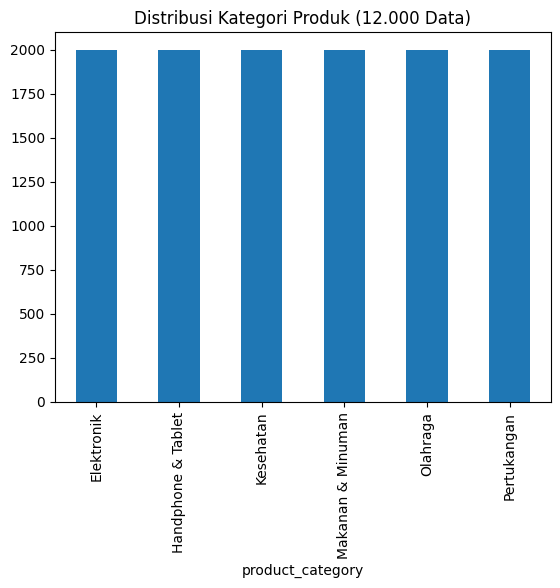

In [7]:
import matplotlib.pyplot as plt
df['product_category'].value_counts().plot(kind='bar')
plt.title('Distribusi Kategori Produk (12.000 Data)')
plt.show()